<a href="https://colab.research.google.com/github/Meowmixforme/Squirrel-Red/blob/main/Notebooks/Squirrel_Red_RandomForestRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install packages
!pip install numpy pandas geopandas scikit-learn matplotlib libpysal pymongo

# Imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal as lps
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import sparse
from pymongo import MongoClient

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.3 MB/s eta 0:00:00


##### Testing Random Forest Regression

#### Created features:
- Spatial: area, perimeter, spatial weights matrix
- Temporal: yearly counts per region

##### Using 3-fold Cross-validation

##### Model Performance:
#### Average R2 = 0.849
#### Average MAE = 69.92 sightings
#### Final model R2 = 0.79

Loading data...

Boundary Data Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geometry         32 non-null     geometry
 1   id               32 non-null     object  
 2   local_authority  32 non-null     object  
 3   code             32 non-null     object  
 4   hectares         32 non-null     float64 
dtypes: float64(1), geometry(1), object(3)
memory usage: 1.4+ KB
None

Sample of boundaries:
                                            geometry         id  \
0  MULTIPOLYGON (((316464.999 776753.496, 316489....  pub_las.1   
1  MULTIPOLYGON (((291801.174 688448.131, 291468....  pub_las.2   
2  MULTIPOLYGON (((332974.704 731066.604, 332829....  pub_las.3   
3  MULTIPOLYGON (((241287.604 653032.301, 241301....  pub_las.4   
4  MULTIPOLYGON (((250190.703 678031.705, 250198....  pub_las.5   

       local_authority      

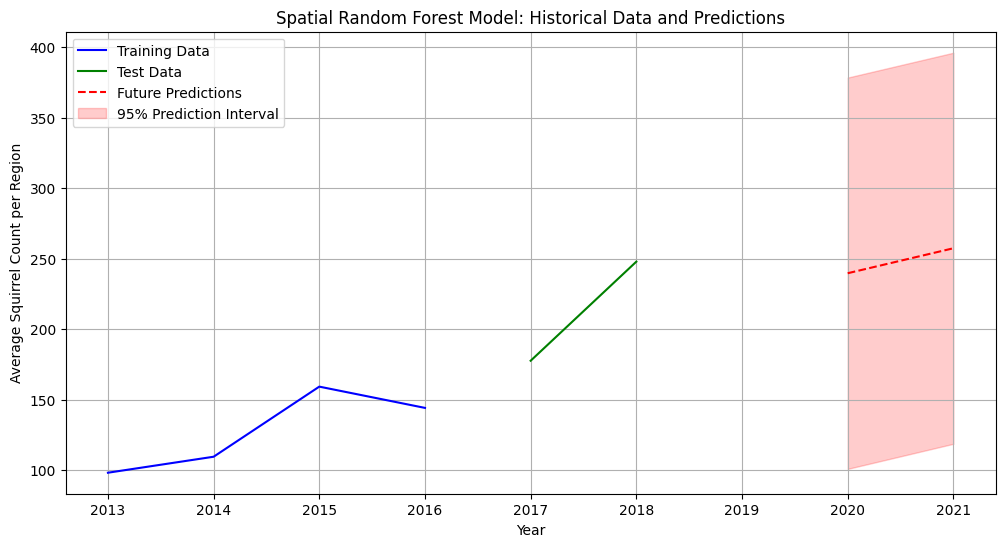


Regional Predictions for 2021:
Angus: 746 (335-1156)
Clackmannanshire: 183 (52-315)
Dundee City: 37 (-18-93)
East Ayrshire: 14 (-6-34)
East Dunbartonshire: 6 (-21-32)
East Renfrewshire: 5 (-22-32)
Falkirk: 17 (1-33)
Glasgow City: 0 (-2-2)
Inverclyde: 6 (-21-34)
Midlothian: 7 (-4-18)
North Lanarkshire: 8 (-3-19)
Perth and Kinross: 842 (632-1052)
Renfrewshire: 2 (-17-21)
Scottish Borders: 422 (-30-874)
South Lanarkshire: 9 (-8-26)
Stirling: 754 (336-1172)
West Dunbartonshire: 110 (-32-253)
West Lothian: 2 (-2-5)
Highland: 815 (541-1090)
Moray: 288 (155-421)
Orkney Islands: 5 (-11-20)
Argyll and Bute: 663 (193-1132)
Aberdeenshire: 848 (662-1033)
Fife: 720 (275-1165)
Aberdeen City: 745 (320-1171)
City of Edinburgh: 3 (-6-11)
East Lothian: 8 (-8-23)
Shetland Islands: 6 (-14-26)
North Ayrshire: 48 (-53-149)
Dumfries and Galloway: 851 (656-1046)
South Ayrshire: 36 (-26-98)
Na h-Eileanan an Iar: 32 (-58-121)

Predictions saved to 'squirrel_predictions.csv'


In [2]:
# Install required packages
!pip install numpy pandas geopandas scikit-learn matplotlib libpysal pymongo dnspython

# Imports
from google.colab import userdata
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal as lps
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import sparse
from pymongo import MongoClient

print("Loading data...")

# Secure MongoDB connection using Colab Secrets
connection_string = userdata.get("SQUIRREL_RED")
if not connection_string:
    raise ValueError("MongoDB URI not found. Please add it in the Colab Secrets sidebar under the name 'SQUIRREL_RED'.")

client = MongoClient(connection_string)


# Load boundaries
boundary_collection = client['Scottish_Boundaries']['Boundary_data']
boundary_data = list(boundary_collection.find())

boundaries = gpd.GeoDataFrame.from_features(boundary_data)
boundaries.set_crs(epsg=4326, inplace=True)
boundaries = boundaries.to_crs('EPSG:27700')


print("\nBoundary Data Info:")
print(boundaries.info())
print("\nSample of boundaries:")
print(boundaries.head())

# Load squirrel data
squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022_filtered"]
squirrel_docs = list(squirrel_collection.find())
squirrel_features = []
for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        properties = {
            'year': doc.get('year'),
            'season': doc.get('season'),
            'Date': doc.get('Date')
        }
        if properties['year'] is None and 'properties' in doc:
            properties['year'] = doc['properties'].get('year')
            properties['season'] = doc['properties'].get('season')
            properties['Date'] = doc['properties'].get('Date')
        feature = {
            'type': 'Feature',
            'geometry': doc['geometry'],
            'properties': properties
        }
        squirrel_features.append(feature)

print(f"\nTotal squirrel features: {len(squirrel_features)}")
print("\nSample squirrel feature:")
print(squirrel_features[0])

# Create spatial features
def create_spatial_features(boundaries):
    print("\nPreparing spatial features")
    boundaries['area'] = boundaries.geometry.area
    boundaries['perimeter'] = boundaries.geometry.length

    print("\nSpatial Features Stats:")
    print(boundaries[['area', 'perimeter']].describe())

    W = lps.weights.KNN.from_dataframe(boundaries, k=4)
    W.transform = 'R'
    return boundaries, W

# Create temporal features
def create_temporal_features(squirrel_features, boundaries):
    print("\nCreating temporal features")
    counts_df = pd.DataFrame(index=boundaries.index)
    boundaries = boundaries.to_crs('EPSG:27700')

    for year in range(2011, 2020):
        year_features = [f for f in squirrel_features if f['properties']['year'] == year]

        if not year_features:
            counts_df[year] = 0
            continue

        year_points = gpd.GeoDataFrame.from_features(year_features)
        year_points.set_crs(epsg=4326, inplace=True)
        year_points = year_points.to_crs('EPSG:27700')

        joined = gpd.sjoin(year_points, boundaries, how='left', predicate='within')
        counts = joined.groupby('index_right').size()
        counts = counts.reindex(boundaries.index, fill_value=0)
        counts_df[year] = counts

        print(f"\nYear {year} statistics:")
        print(f"Total records: {len(year_features)}")
        print(f"Points with valid spatial join: {len(joined)}")
        print("Count statistics:")
        print(counts.describe())

    return counts_df

# Create feature matrix
def create_feature_matrix(boundaries, counts_df, year, W):
    X = pd.DataFrame(index=boundaries.index)
    X['area'] = boundaries['area'] / 1e6
    X['density'] = counts_df[year]
    X['prev_year_count'] = counts_df[year-1] if year > 2011 else counts_df[year]
    X['spatial_lag'] = sparse.csr_matrix(W.sparse).dot(counts_df[year])

    print(f"\nFeature Matrix Stats for {year}:")
    print(X.describe())

    return X

# Prepare data
boundaries, W = create_spatial_features(boundaries)
counts_df = create_temporal_features(squirrel_features, boundaries)

print("\nCounts DataFrame Info:")
print(counts_df.info())
print("\nCounts Summary Statistics:")
print(counts_df.describe())

# Create feature matrices
print("\nCreating feature matrices")
data_frames = []
for year in range(2013, 2019):
    X = create_feature_matrix(boundaries, counts_df, year, W)
    y = counts_df[year+1]

    print(f"\nTarget values for {year+1}:")
    print(y.describe())

    year_df = X.copy()
    year_df['year'] = year
    year_df['target'] = y
    year_df['region'] = boundaries['local_authority']
    data_frames.append(year_df)

data_df = pd.concat(data_frames, axis=0)

print("\nFinal Dataset Info:")
print(data_df.info())
print("\nFinal Dataset Summary:")
print(data_df.describe())

# Cross-validation
print("\nPerforming Time Series Cross-Validation")
feature_cols = ['area', 'density', 'prev_year_count', 'spatial_lag']
tscv = TimeSeriesSplit(n_splits=3)
years = data_df['year'].unique()
cv_scores = {'r2': [], 'mse': [], 'mae': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(years)):
    train_years = years[train_idx]
    val_year = years[val_idx]

    print(f"\nFold {fold + 1}:")
    print(f"Training years: {train_years}")
    print(f"Validation year: {val_year}")

    train_mask = data_df['year'].isin(train_years)
    val_mask = data_df['year'].isin(val_year)

    X_train_cv = data_df[train_mask][feature_cols]
    y_train_cv = data_df[train_mask]['target']
    X_val_cv = data_df[val_mask][feature_cols]
    y_val_cv = data_df[val_mask]['target']

    scaler_cv = StandardScaler()
    X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)
    X_val_cv_scaled = scaler_cv.transform(X_val_cv)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    )

    model.fit(X_train_cv_scaled, y_train_cv)
    y_pred_cv = model.predict(X_val_cv_scaled)

    r2 = r2_score(y_val_cv, y_pred_cv)
    mse = mean_squared_error(y_val_cv, y_pred_cv)
    mae = mean_absolute_error(y_val_cv, y_pred_cv)

    cv_scores['r2'].append(r2)
    cv_scores['mse'].append(mse)
    cv_scores['mae'].append(mae)

    print(f"R2 Score: {r2:.3f}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")

print("\nCross-Validation Summary:")
print(f"Average R2 Score: {np.mean(cv_scores['r2']):.3f} (+/-{np.std(cv_scores['r2']):.3f})")
print(f"Average MSE: {np.mean(cv_scores['mse']):.2f} (+/-{np.std(cv_scores['mse']):.2f})")
print(f"Average MAE: {np.mean(cv_scores['mae']):.2f} (+/-{np.std(cv_scores['mae']):.2f})")

# Final model training
print("\nTraining final model")
train_years = list(range(2013, 2017))
test_years = list(range(2017, 2019))

train_mask = data_df['year'].isin(train_years)
test_mask = data_df['year'].isin(test_years)

X_train = data_df[train_mask][feature_cols]
X_test = data_df[test_mask][feature_cols]
y_train = data_df[train_mask]['target']
y_test = data_df[test_mask]['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
y_pred_test = rf_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nFinal Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

# Future predictions
print("\nMaking future predictions")
future_predictions = {}
for year in range(2020, 2022):
    X_future = create_feature_matrix(boundaries, counts_df, year-1, W)
    X_future_scaled = scaler.transform(X_future)

    predictions = []
    for estimator in rf_model.estimators_:
        predictions.append(estimator.predict(X_future_scaled))
    predictions = np.array(predictions)

    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)

    future_predictions[year] = {
        'mean': mean_pred,
        'lower': mean_pred - 1.96 * std_pred,
        'upper': mean_pred + 1.96 * std_pred
    }
    counts_df[year] = mean_pred

# Visualization
plt.figure(figsize=(12, 6))
train_years = np.array(train_years)
test_years = np.array(test_years)
future_years = np.array(list(future_predictions.keys()))

train_means = [counts_df[year].mean() for year in train_years]
test_means = [counts_df[year].mean() for year in test_years]
future_means = [future_predictions[year]['mean'].mean() for year in future_years]
future_lower = [future_predictions[year]['lower'].mean() for year in future_years]
future_upper = [future_predictions[year]['upper'].mean() for year in future_years]

plt.plot(train_years, train_means, 'b-', label='Training Data')
plt.plot(test_years, test_means, 'g-', label='Test Data')
plt.plot(future_years, future_means, 'r--', label='Future Predictions')
plt.fill_between(future_years, future_lower, future_upper, color='r', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Year')
plt.ylabel('Average Squirrel Count per Region')
plt.title('Spatial Random Forest Model: Historical Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Print regional predictions
print("\nRegional Predictions for 2021:")
for region in boundaries['local_authority']:
    idx = boundaries[boundaries['local_authority'] == region].index[0]
    mean = future_predictions[2021]['mean'][idx]
    lower = future_predictions[2021]['lower'][idx]
    upper = future_predictions[2021]['upper'][idx]
    print(f"{region}: {mean:.0f} ({lower:.0f}-{upper:.0f})")

# Save predictions
predictions_df = pd.DataFrame(index=boundaries['local_authority'])
for year in future_predictions:
    predictions_df[f'{year}_mean'] = future_predictions[year]['mean']
    predictions_df[f'{year}_lower'] = future_predictions[year]['lower']
    predictions_df[f'{year}_upper'] = future_predictions[year]['upper']

predictions_df.to_csv('squirrel_predictions.csv')
print("\nPredictions saved to 'squirrel_predictions.csv'")

##### Extending to 2030

##### The cross-validation shows good performance with R2 scores ranging from 0.805 to 0.879.
##### The final model's R2 of 0.79 is slightly lower but still good.
##### MAE increases from training to test set (69.92 to 91.65), suggests some decline in accuracy for future predictions.
##### Feature Importance:
##### Density is the most important feature (50.8%)
##### Previous year count is second (35.5%)
##### Area is third (13.2%)
##### Spatial lag has a minimal impact (0.5%)

To 2030

Loading data...
Loading data

Boundary Data Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geometry         32 non-null     geometry
 1   id               32 non-null     object  
 2   local_authority  32 non-null     object  
 3   code             32 non-null     object  
 4   hectares         32 non-null     float64 
dtypes: float64(1), geometry(1), object(3)
memory usage: 1.4+ KB
None

Sample of boundaries:
                                            geometry         id  \
0  MULTIPOLYGON (((316464.999 776753.496, 316489....  pub_las.1   
1  MULTIPOLYGON (((291801.174 688448.131, 291468....  pub_las.2   
2  MULTIPOLYGON (((332974.704 731066.604, 332829....  pub_las.3   
3  MULTIPOLYGON (((241287.604 653032.301, 241301....  pub_las.4   
4  MULTIPOLYGON (((250190.703 678031.705, 250198....  pub_las.5   

       local_au

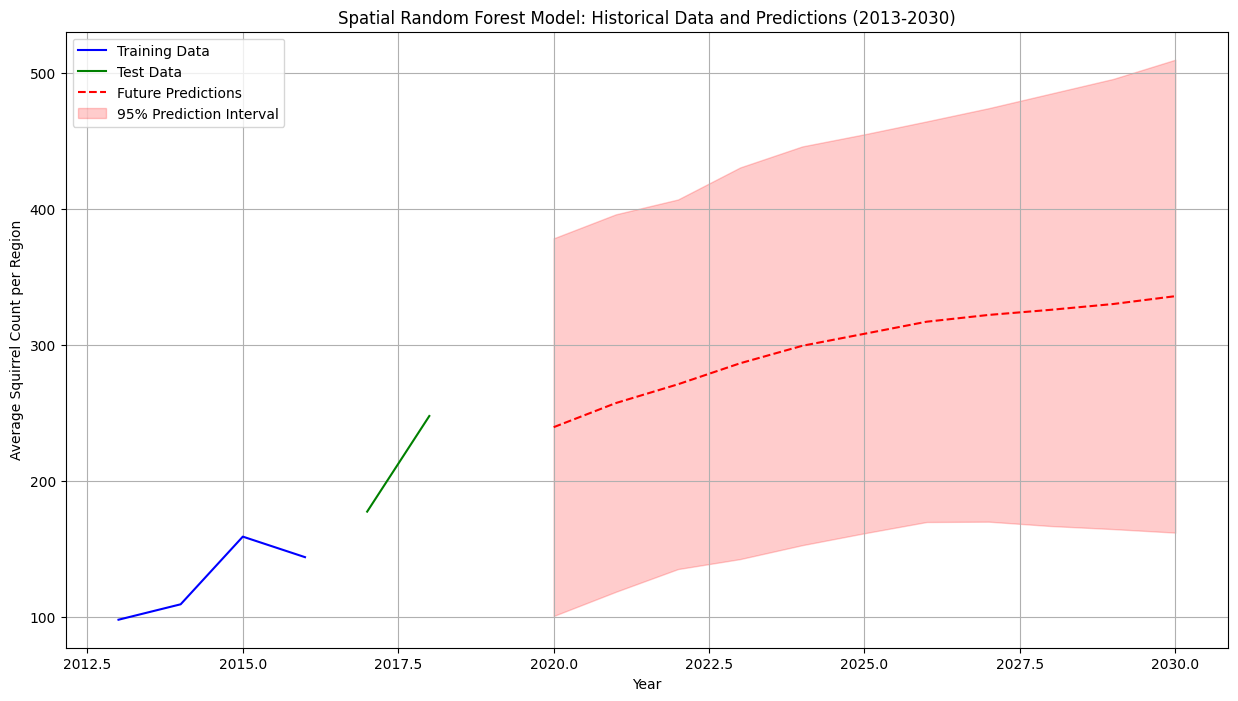


Regional Predictions for selected years:

Angus:
2025: 748 (336-1161)
2030: 748 (336-1161)

Clackmannanshire:
2025: 268 (123-412)
2030: 269 (123-415)

Dundee City:
2025: 203 (39-368)
2030: 320 (113-527)

East Ayrshire:
2025: 17 (1-33)
2030: 17 (1-32)

East Dunbartonshire:
2025: 19 (-10-47)
2030: 63 (-59-186)

East Renfrewshire:
2025: 19 (-10-47)
2030: 63 (-59-186)

Falkirk:
2025: 35 (-21-90)
2030: 193 (81-305)

Glasgow City:
2025: 9 (-18-36)
2030: 30 (-21-80)

Inverclyde:
2025: 19 (-9-48)
2030: 63 (-59-186)

Midlothian:
2025: 18 (-1-38)
2030: 47 (-42-136)

North Lanarkshire:
2025: 18 (-6-42)
2030: 41 (-39-120)

Perth and Kinross:
2025: 842 (632-1052)
2030: 842 (632-1052)

Renfrewshire:
2025: 14 (-0-28)
2030: 34 (-21-90)

Scottish Borders:
2025: 758 (344-1172)
2030: 760 (342-1178)

South Lanarkshire:
2025: 18 (-8-43)
2030: 36 (-27-98)

Stirling:
2025: 748 (332-1163)
2030: 748 (332-1163)

West Dunbartonshire:
2025: 268 (127-408)
2030: 268 (124-412)

West Lothian:
2025: 15 (-7-38)
2030: 

In [3]:
# Install required packages
!pip install numpy pandas geopandas scikit-learn matplotlib libpysal pymongo dnspython

# Imports
from google.colab import userdata
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal as lps
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import sparse
from pymongo import MongoClient

print("Loading data...")

# Secure MongoDB connection using Colab Secrets
connection_string = userdata.get("SQUIRREL_RED")
if not connection_string:
    raise ValueError("MongoDB URI not found. Please add it in the Colab Secrets sidebar under the name 'SQUIRREL_RED'.")

client = MongoClient(connection_string)

print("Loading data")


# Load boundaries
boundary_collection = client['Scottish_Boundaries']['Boundary_data']
boundary_data = list(boundary_collection.find())
boundaries = gpd.GeoDataFrame.from_features(boundary_data)
boundaries.set_crs(epsg=4326, inplace=True)
boundaries = boundaries.to_crs('EPSG:27700')

print("\nBoundary Data Info:")
print(boundaries.info())
print("\nSample of boundaries:")
print(boundaries.head())

# Load squirrel data
squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022_filtered"]
squirrel_docs = list(squirrel_collection.find())
squirrel_features = []
for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        properties = {
            'year': doc.get('year'),
            'season': doc.get('season'),
            'Date': doc.get('Date')
        }
        if properties['year'] is None and 'properties' in doc:
            properties['year'] = doc['properties'].get('year')
            properties['season'] = doc['properties'].get('season')
            properties['Date'] = doc['properties'].get('Date')
        feature = {
            'type': 'Feature',
            'geometry': doc['geometry'],
            'properties': properties
        }
        squirrel_features.append(feature)

print(f"\nTotal squirrel features: {len(squirrel_features)}")
print("\nSample squirrel feature:")
print(squirrel_features[0])

# Create spatial features
def create_spatial_features(boundaries):
    print("\nPreparing spatial features")
    boundaries['area'] = boundaries.geometry.area
    boundaries['perimeter'] = boundaries.geometry.length

    print("\nSpatial Features Stats:")
    print(boundaries[['area', 'perimeter']].describe())

    W = lps.weights.KNN.from_dataframe(boundaries, k=4)
    W.transform = 'R'
    return boundaries, W

# Create temporal features
def create_temporal_features(squirrel_features, boundaries):
    print("\nCreating temporal features")
    counts_df = pd.DataFrame(index=boundaries.index)
    boundaries = boundaries.to_crs('EPSG:27700')

    for year in range(2011, 2020):
        year_features = [f for f in squirrel_features if f['properties']['year'] == year]

        if not year_features:
            counts_df[year] = 0
            continue

        year_points = gpd.GeoDataFrame.from_features(year_features)
        year_points.set_crs(epsg=4326, inplace=True)
        year_points = year_points.to_crs('EPSG:27700')

        joined = gpd.sjoin(year_points, boundaries, how='left', predicate='within')
        counts = joined.groupby('index_right').size()
        counts = counts.reindex(boundaries.index, fill_value=0)
        counts_df[year] = counts

        print(f"\nYear {year} statistics:")
        print(f"Total records: {len(year_features)}")
        print(f"Points with valid spatial join: {len(joined)}")
        print("Count statistics:")
        print(counts.describe())

    return counts_df

# Create feature matrix
def create_feature_matrix(boundaries, counts_df, year, W):
    X = pd.DataFrame(index=boundaries.index)
    X['area'] = boundaries['area'] / 1e6 # to km
    X['density'] = counts_df[year]
    X['prev_year_count'] = counts_df[year-1] if year > 2011 else counts_df[year]
    X['spatial_lag'] = sparse.csr_matrix(W.sparse).dot(counts_df[year])

    print(f"\nFeature Matrix Stats for {year}:")
    print(X.describe())

    return X

# Prepare data
boundaries, W = create_spatial_features(boundaries)
counts_df = create_temporal_features(squirrel_features, boundaries)

# Create feature matrices
print("\nCreating feature matrices")
data_frames = []
for year in range(2013, 2019):
    X = create_feature_matrix(boundaries, counts_df, year, W)
    y = counts_df[year+1]
    year_df = X.copy()
    year_df['year'] = year
    year_df['target'] = y
    year_df['region'] = boundaries['local_authority']
    data_frames.append(year_df)

data_df = pd.concat(data_frames, axis=0)

print("\nFinal Dataset Info:")
print(data_df.info())
print("\nFinal Dataset Summary:")
print(data_df.describe())

# Cross-validation
print("\nPerforming Time Series Cross-Validation")
feature_cols = ['area', 'density', 'prev_year_count', 'spatial_lag']
tscv = TimeSeriesSplit(n_splits=3)
years = data_df['year'].unique()
cv_scores = {'r2': [], 'mse': [], 'mae': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(years)):
    train_years = years[train_idx]
    val_year = years[val_idx]

    print(f"\nFold {fold + 1}:")
    print(f"Training years: {train_years}")
    print(f"Validation year: {val_year}")

    train_mask = data_df['year'].isin(train_years)
    val_mask = data_df['year'].isin(val_year)

    X_train_cv = data_df[train_mask][feature_cols]
    y_train_cv = data_df[train_mask]['target']
    X_val_cv = data_df[val_mask][feature_cols]
    y_val_cv = data_df[val_mask]['target']

    scaler_cv = StandardScaler()
    X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)
    X_val_cv_scaled = scaler_cv.transform(X_val_cv)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    )

    model.fit(X_train_cv_scaled, y_train_cv)
    y_pred_cv = model.predict(X_val_cv_scaled)

    r2 = r2_score(y_val_cv, y_pred_cv)
    mse = mean_squared_error(y_val_cv, y_pred_cv)
    mae = mean_absolute_error(y_val_cv, y_pred_cv)

    cv_scores['r2'].append(r2)
    cv_scores['mse'].append(mse)
    cv_scores['mae'].append(mae)

    print(f"R2 Score: {r2:.3f}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")

print("\nCross-Validation Summary:")
print(f"Average R2 Score: {np.mean(cv_scores['r2']):.3f} (+/-{np.std(cv_scores['r2']):.3f})")
print(f"Average MSE: {np.mean(cv_scores['mse']):.2f} (+/-{np.std(cv_scores['mse']):.2f})")
print(f"Average MAE: {np.mean(cv_scores['mae']):.2f} (+/-{np.std(cv_scores['mae']):.2f})")

# Final model training
print("\nTraining final model")
train_years = list(range(2013, 2017))
test_years = list(range(2017, 2019))

train_mask = data_df['year'].isin(train_years)
test_mask = data_df['year'].isin(test_years)

X_train = data_df[train_mask][feature_cols]
X_test = data_df[test_mask][feature_cols]
y_train = data_df[train_mask]['target']
y_test = data_df[test_mask]['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
y_pred_test = rf_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nFinal Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

# Future predictions
print("\nMaking future predictions")
future_predictions = {}
for year in range(2020, 2031):  # Extended to 2030
    X_future = create_feature_matrix(boundaries, counts_df, year-1, W)
    X_future_scaled = scaler.transform(X_future)

    predictions = []
    for estimator in rf_model.estimators_:
        predictions.append(estimator.predict(X_future_scaled))
    predictions = np.array(predictions)

    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)

    future_predictions[year] = {
        'mean': mean_pred,
        'lower': mean_pred - 1.96 * std_pred,
        'upper': mean_pred + 1.96 * std_pred
    }
    counts_df[year] = mean_pred

# Visualization
plt.figure(figsize=(15, 8))
train_years = np.array(train_years)
test_years = np.array(test_years)
future_years = np.array(list(future_predictions.keys()))

train_means = [counts_df[year].mean() for year in train_years]
test_means = [counts_df[year].mean() for year in test_years]
future_means = [future_predictions[year]['mean'].mean() for year in future_years]
future_lower = [future_predictions[year]['lower'].mean() for year in future_years]
future_upper = [future_predictions[year]['upper'].mean() for year in future_years]

plt.plot(train_years, train_means, 'b-', label='Training Data')
plt.plot(test_years, test_means, 'g-', label='Test Data')
plt.plot(future_years, future_means, 'r--', label='Future Predictions')
plt.fill_between(future_years, future_lower, future_upper, color='r', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Year')
plt.ylabel('Average Squirrel Count per Region')
plt.title('Spatial Random Forest Model: Historical Data and Predictions (2013-2030)')
plt.legend()
plt.grid(True)
plt.show()

# Print regional predictions
print("\nRegional Predictions for selected years:")
for region in boundaries['local_authority']:
    idx = boundaries[boundaries['local_authority'] == region].index[0]
    predictions = {
        year: (
            future_predictions[year]['mean'][idx],
            future_predictions[year]['lower'][idx],
            future_predictions[year]['upper'][idx]
        )
        for year in [2025, 2030]
    }
    print(f"\n{region}:")
    for year, (mean, lower, upper) in predictions.items():
        print(f"{year}: {mean:.0f} ({lower:.0f}-{upper:.0f})")

# Save predictions
predictions_df = pd.DataFrame(index=boundaries['local_authority'])
for year in future_predictions:
    predictions_df[f'{year}_mean'] = future_predictions[year]['mean']
    predictions_df[f'{year}_lower'] = future_predictions[year]['lower']
    predictions_df[f'{year}_upper'] = future_predictions[year]['upper']

predictions_df.to_csv('squirrel_predictions.csv')
print("\nPredictions saved to 'squirrel_predictions.csv'")

##### GridSearch Cross-Validation to search for optimal values.

##### We can see the best values are:

##### 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200



Loading data...
Loading data

Preparing spatial features

Creating temporal features

Creating feature matrices

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             192 non-null    float64
 1   density          192 non-null    int64  
 2   prev_year_count  192 non-null    int64  
 3   spatial_lag      192 non-null    float64
 4   year             192 non-null    int64  
 5   target           192 non-null    int64  
 6   region           192 non-null    object 
dtypes: float64(2), int64(4), object(1)
memory usage: 12.0+ KB
None

Final Dataset Summary:
               area      density  prev_year_count  spatial_lag        year  \
count    192.000000   192.000000       192.000000   192.000000   192.00000   
mean    2507.233652   156.104167       133.562500   124.498698  2015.50000   
std     4781.602680   291.036

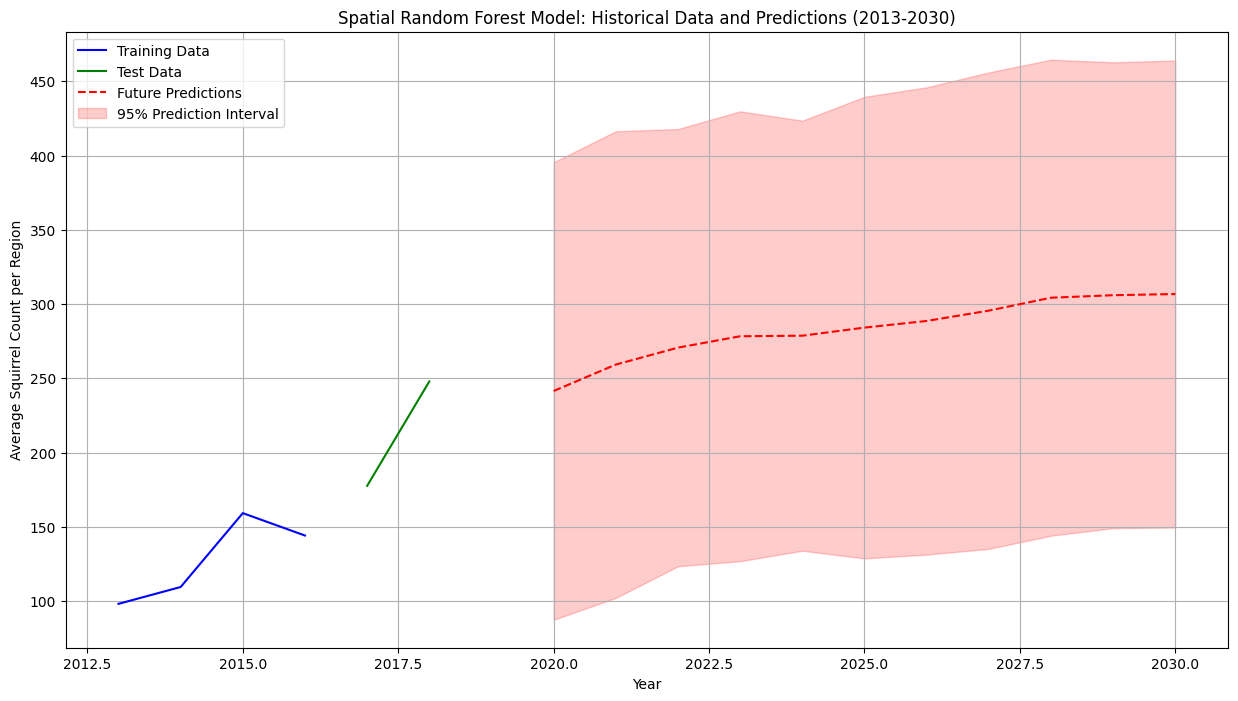


Regional Predictions for selected years:

Angus:
2025: 774 (283-1265)
2030: 783 (280-1285)

Clackmannanshire:
2025: 275 (109-440)
2030: 280 (110-451)

Dundee City:
2025: 59 (-65-184)
2030: 292 (155-428)

East Ayrshire:
2025: 12 (4-20)
2030: 12 (4-20)

East Dunbartonshire:
2025: 12 (-2-27)
2030: 14 (-2-30)

East Renfrewshire:
2025: 11 (-4-25)
2030: 14 (-2-30)

Falkirk:
2025: 14 (-2-30)
2030: 14 (-2-30)

Glasgow City:
2025: 11 (-3-26)
2030: 14 (-2-30)

Inverclyde:
2025: 11 (-4-25)
2030: 14 (-2-30)

Midlothian:
2025: 13 (-2-29)
2030: 14 (-1-30)

North Lanarkshire:
2025: 12 (-1-26)
2030: 12 (-1-26)

Perth and Kinross:
2025: 860 (546-1175)
2030: 860 (546-1175)

Renfrewshire:
2025: 11 (-4-25)
2030: 14 (-2-30)

Scottish Borders:
2025: 421 (-28-870)
2030: 835 (348-1323)

South Lanarkshire:
2025: 12 (4-20)
2030: 12 (4-20)

Stirling:
2025: 815 (336-1295)
2030: 808 (336-1280)

West Dunbartonshire:
2025: 259 (98-419)
2030: 279 (111-446)

West Lothian:
2025: 11 (-3-25)
2030: 14 (-2-30)

Highland:


In [5]:
# Install required packages
!pip install numpy pandas geopandas scikit-learn matplotlib libpysal pymongo dnspython

# Imports
from google.colab import userdata
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal as lps
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from scipy import sparse
from pymongo import MongoClient

print("Loading data...")

# Secure MongoDB connection using Colab Secrets
connection_string = userdata.get("SQUIRREL_RED")
if not connection_string:
    raise ValueError("MongoDB URI not found. Please add it in the Colab Secrets sidebar under the name 'SQUIRREL_RED'.")

client = MongoClient(connection_string)

print("Loading data")


# Load boundaries and squirrel data
boundary_collection = client['Scottish_Boundaries']['Boundary_data']
boundary_data = list(boundary_collection.find())
boundaries = gpd.GeoDataFrame.from_features(boundary_data)
boundaries.set_crs(epsg=4326, inplace=True)
boundaries = boundaries.to_crs('EPSG:27700')

squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022_filtered"]
squirrel_docs = list(squirrel_collection.find())
squirrel_features = []
for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        properties = {
            'year': doc.get('year'),
            'season': doc.get('season'),
            'Date': doc.get('Date')
        }
        if properties['year'] is None and 'properties' in doc:
            properties['year'] = doc['properties'].get('year')
            properties['season'] = doc['properties'].get('season')
            properties['Date'] = doc['properties'].get('Date')
        feature = {
            'type': 'Feature',
            'geometry': doc['geometry'],
            'properties': properties
        }
        squirrel_features.append(feature)

# Create spatial features
def create_spatial_features(boundaries):
    print("\nPreparing spatial features")
    boundaries['area'] = boundaries.geometry.area
    boundaries['perimeter'] = boundaries.geometry.length
    W = lps.weights.KNN.from_dataframe(boundaries, k=4)
    W.transform = 'R'
    return boundaries, W

# Create temporal features
def create_temporal_features(squirrel_features, boundaries):
    print("\nCreating temporal features")
    counts_df = pd.DataFrame(index=boundaries.index)
    boundaries = boundaries.to_crs('EPSG:27700')

    for year in range(2011, 2020):
        year_features = [f for f in squirrel_features if f['properties']['year'] == year]
        if not year_features:
            counts_df[year] = 0
            continue

        year_points = gpd.GeoDataFrame.from_features(year_features)
        year_points.set_crs(epsg=4326, inplace=True)
        year_points = year_points.to_crs('EPSG:27700')

        joined = gpd.sjoin(year_points, boundaries, how='left', predicate='within')
        counts = joined.groupby('index_right').size()
        counts = counts.reindex(boundaries.index, fill_value=0)
        counts_df[year] = counts

    return counts_df

# Create feature matrix
def create_feature_matrix(boundaries, counts_df, year, W):
    X = pd.DataFrame(index=boundaries.index)
    X['area'] = boundaries['area'] / 1e6
    X['density'] = counts_df[year]
    X['prev_year_count'] = counts_df[year-1] if year > 2011 else counts_df[year]
    X['spatial_lag'] = sparse.csr_matrix(W.sparse).dot(counts_df[year])
    return X

# Prepare data
boundaries, W = create_spatial_features(boundaries)
counts_df = create_temporal_features(squirrel_features, boundaries)

# Create feature matrices
print("\nCreating feature matrices")
data_frames = []
for year in range(2013, 2019):
    X = create_feature_matrix(boundaries, counts_df, year, W)
    y = counts_df[year+1]
    year_df = X.copy()
    year_df['year'] = year
    year_df['target'] = y
    year_df['region'] = boundaries['local_authority']
    data_frames.append(year_df)

data_df = pd.concat(data_frames, axis=0)

print("\nFinal Dataset Info:")
print(data_df.info())
print("\nFinal Dataset Summary:")
print(data_df.describe())

# Prepare for model training
feature_cols = ['area', 'density', 'prev_year_count', 'spatial_lag']
train_years = list(range(2013, 2017))
test_years = list(range(2017, 2019))

train_mask = data_df['year'].isin(train_years)
test_mask = data_df['year'].isin(test_years)

X_train = data_df[train_mask][feature_cols]
X_test = data_df[test_mask][feature_cols]
y_train = data_df[train_mask]['target']
y_test = data_df[test_mask]['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Create base model
rf_base = RandomForestRegressor(random_state=42)

# Create time series split
tscv = TimeSeriesSplit(n_splits=3)

# Create GridSearchCV object
print("\nPerforming grid search")
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Print best parameters and score
print("\nBest parameters:")
print(grid_search.best_params_)
print(f"\nBest MSE: {-grid_search.best_score_:.2f}")

# Use best model for predictions
rf_model = grid_search.best_estimator_

# Evaluate on test set
y_pred_test = rf_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nOptimized Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

# Future predictions
print("\nMaking future predictions")
future_predictions = {}
for year in range(2020, 2031):
    X_future = create_feature_matrix(boundaries, counts_df, year-1, W)
    X_future_scaled = scaler.transform(X_future)

    predictions = []
    for estimator in rf_model.estimators_:
        predictions.append(estimator.predict(X_future_scaled))
    predictions = np.array(predictions)

    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)

    future_predictions[year] = {
        'mean': mean_pred,
        'lower': mean_pred - 1.96 * std_pred,
        'upper': mean_pred + 1.96 * std_pred
    }
    counts_df[year] = mean_pred

# Visualization
plt.figure(figsize=(15, 8))
train_years = np.array(train_years)
test_years = np.array(test_years)
future_years = np.array(list(future_predictions.keys()))

train_means = [counts_df[year].mean() for year in train_years]
test_means = [counts_df[year].mean() for year in test_years]
future_means = [future_predictions[year]['mean'].mean() for year in future_years]
future_lower = [future_predictions[year]['lower'].mean() for year in future_years]
future_upper = [future_predictions[year]['upper'].mean() for year in future_years]

plt.plot(train_years, train_means, 'b-', label='Training Data')
plt.plot(test_years, test_means, 'g-', label='Test Data')
plt.plot(future_years, future_means, 'r--', label='Future Predictions')
plt.fill_between(future_years, future_lower, future_upper, color='r', alpha=0.2, label='95% Prediction Interval')

plt.xlabel('Year')
plt.ylabel('Average Squirrel Count per Region')
plt.title('Spatial Random Forest Model: Historical Data and Predictions (2013-2030)')
plt.legend()
plt.grid(True)
plt.show()

# Print regional predictions
print("\nRegional Predictions for selected years:")
for region in boundaries['local_authority']:
    idx = boundaries[boundaries['local_authority'] == region].index[0]
    predictions = {
        year: (
            future_predictions[year]['mean'][idx],
            future_predictions[year]['lower'][idx],
            future_predictions[year]['upper'][idx]
        )
        for year in [2025, 2030]
    }
    print(f"\n{region}:")
    for year, (mean, lower, upper) in predictions.items():
        print(f"{year}: {mean:.0f} ({lower:.0f}-{upper:.0f})")

# Save predictions
predictions_df = pd.DataFrame(index=boundaries['local_authority'])
for year in future_predictions:
    predictions_df[f'{year}_mean'] = future_predictions[year]['mean']
    predictions_df[f'{year}_lower'] = future_predictions[year]['lower']
    predictions_df[f'{year}_upper'] = future_predictions[year]['upper']

predictions_df.to_csv('squirrel_predictions_optimized.csv')
print("\nPredictions saved to 'squirrel_predictions_optimized.csv'")